В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/edce80b5bb02479085855b2334b17fc1). Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import learning_curve
from sklearn.feature_selection import SelectKBest, f_regression

In [2]:
def plot_learning_curve(
    estimator,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    problem_type="classification",
    train_sizes=np.linspace(0.1, 1.0, 10),
    title="Learning Curve"
):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    plt.plot(train_sizes, train_mean, marker='o', label=f'Train {scoring}')
    plt.plot(train_sizes, val_mean, marker='s', label=f'Validation {scoring}')
    plt.xlabel("Training size")
    plt.ylabel(scoring)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

Train ROC AUC: 0.88


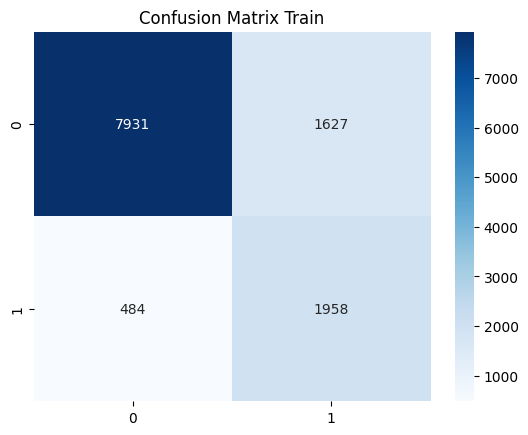

Validation ROC AUC: 0.88


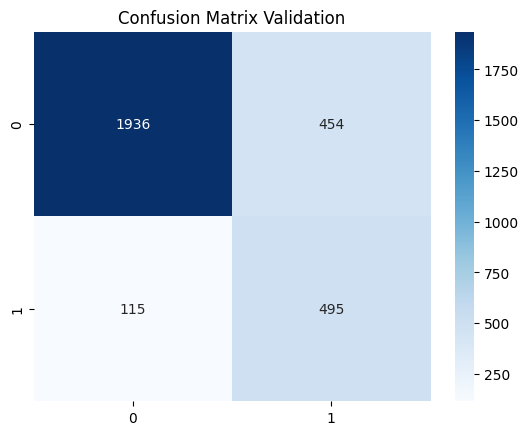

['data_hw_2_2/pipeline_logreg.joblib']

In [3]:
train_df = pd.read_csv("../../data/data_kaggle_01/train.csv")
test_df = pd.read_csv("../../data/data_kaggle_01/test.csv")
sample_submission = pd.read_csv("../../data/data_kaggle_01/sample_submission.csv")

input_cols = [
    'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
    'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]
target_col = 'Exited'

X = train_df[input_cols]
y = train_df[target_col]

train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = train_inputs.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()


# Додаємо AgeGroup
for df in [train_inputs, val_inputs]:
    df['AgeGroup'] = pd.cut(
        df['Age'],
        bins=[18, 30, 40, 50, 60, 100],
        labels=['18-30', '30-40', '40-50', '50-60', '60+']
    )


# Трансформери
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Пайплайн
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Навчання
model_pipeline.fit(train_inputs, train_targets)

# Функція для метрик
def predict_and_plot(pipe, X, y, name=''):
    y_pred = pipe.predict(X)
    roc = roc_auc_score(y, pipe.predict_proba(X)[:,1])
    cm = confusion_matrix(y, y_pred)
    print(f"{name} ROC AUC: {roc:.2f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix {name}')
    plt.show()
    return y_pred

train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds   = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# 10. Збереження
joblib.dump(model_pipeline, 'data_hw_2_2/pipeline_logreg.joblib')

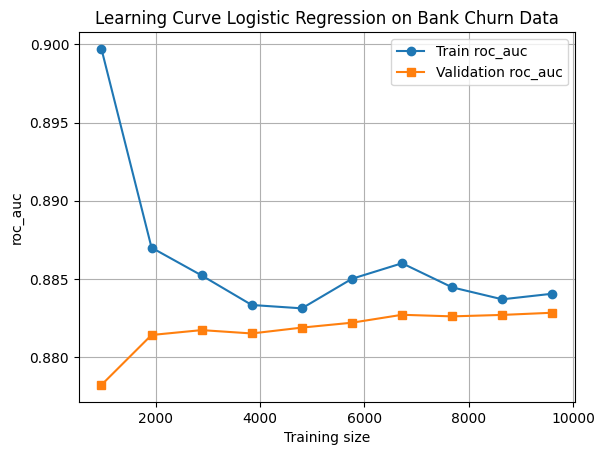

In [4]:
plot_learning_curve(
    estimator=model_pipeline,
    X=train_inputs,
    y=train_targets,
    cv=5,
    scoring="roc_auc",
    problem_type="classification",
    title="Learning Curve Logistic Regression on Bank Churn Data"
)

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [5]:
# числовий пайплайн
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# категоріальний пайплайн
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# колонковий трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# пайплайн
model_pipeline_features_02 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# тренування
model_pipeline_features_02.fit(train_inputs, train_targets)

# оцінка
from sklearn.metrics import roc_auc_score, confusion_matrix

train_preds = model_pipeline_features_02.predict_proba(train_inputs)[:,1]
val_preds = model_pipeline_features_02.predict_proba(val_inputs)[:,1]

print(f"Train ROC AUC: {roc_auc_score(train_targets, train_preds):.3f}")
print(f"Validation ROC AUC: {roc_auc_score(val_targets, val_preds):.3f}")

print(confusion_matrix(train_targets, train_preds > 0.5))
print(confusion_matrix(val_targets, val_preds > 0.5))

Train ROC AUC: 0.931
Validation ROC AUC: 0.928
[[9167  391]
 [ 791 1651]]
[[2271  119]
 [ 196  414]]


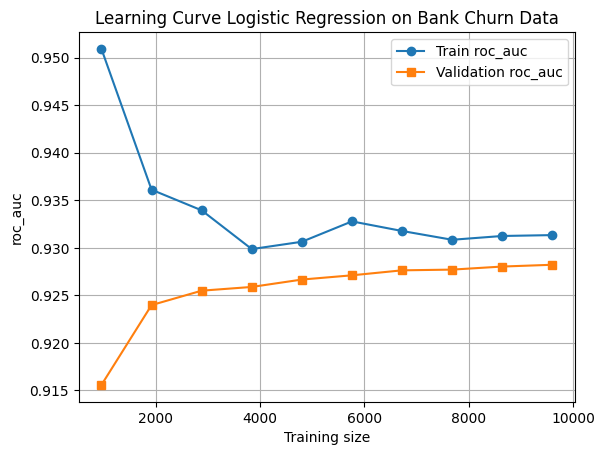

In [6]:
plot_learning_curve(
    estimator=model_pipeline_features_02,
    X=train_inputs,
    y=train_targets,
    cv=5,
    scoring="roc_auc",
    problem_type="classification",
    title="Learning Curve Logistic Regression on Bank Churn Data"
)

**Висновок**
- поліноміальні фічі підняли якість моделі порівняно з попереднім (було ~0.88), тобто модель генералізує краще
- модель після додавання поліноміальних ознак генералізує добре
- не спостерігається ні overfit, ні underfit

In [7]:
test_preds = model_pipeline_features_02.predict_proba(test_df)[:, 1]
sample_submission["Exited"] = test_preds

sample_submission.head()

,id,Exited
0,15000,0.091235
1,15001,0.014654
2,15002,0.071588
3,15003,0.373664
4,15004,0.024321


In [8]:
sample_submission.to_csv('data_hw_2_2/submission_log_reg_02.csv', index=False)

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

In [9]:
# 1. числовий трансформер
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

# 2. категоріальний трансформер
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. колонковий трансформер
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# 4. модель
model_pipeline_4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 5. тренуємо
model_pipeline_4.fit(train_inputs, train_targets)

# 6. оцінка
train_preds = model_pipeline_4.predict_proba(train_inputs)[:,1]
val_preds = model_pipeline_4.predict_proba(val_inputs)[:,1]

print(f"Train ROC AUC: {roc_auc_score(train_targets, train_preds):.3f}")
print(f"Validation ROC AUC: {roc_auc_score(val_targets, val_preds):.3f}")

print("Train confusion matrix:")
print(confusion_matrix(train_targets, train_preds > 0.5))

print("Validation confusion matrix:")
print(confusion_matrix(val_targets, val_preds > 0.5))

Train ROC AUC: 0.946
Validation ROC AUC: 0.922
Train confusion matrix:
[[8342 1216]
 [ 314 2128]]
Validation confusion matrix:
[[2043  347]
 [  94  516]]


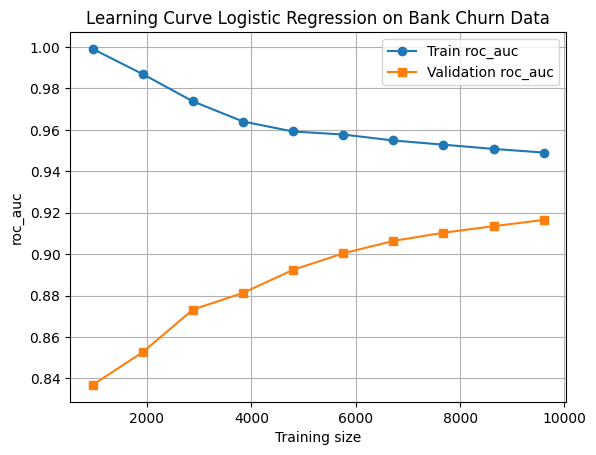

In [10]:
plot_learning_curve(
    estimator=model_pipeline_4,
    X=train_inputs,
    y=train_targets,
    cv=5,
    scoring="roc_auc",
    problem_type="classification",
    title="Learning Curve Logistic Regression on Bank Churn Data"
)

**Модель поліном 4 ступеня — занадто складна для цих даних і схильна до перенавчання, погіршуючи узагальнюючу здатність**

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [11]:
train_df_reg = pd.read_csv("../../data/regression_data.csv")
train_df_reg.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [12]:
# X, y
X = train_df_reg.drop(columns="target")
y = train_df_reg["target"]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=5)),
    ('reg', LinearRegression())
])

pipeline.fit(X_train, y_train)

# predictions
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 0.00
Test RMSE: 35.63


**Висновок: модель має сильне перенавчання (overfitting) і не генералізує добре**

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [13]:
degree = 20

In [14]:
# Аналіз важливості ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
poly = PolynomialFeatures(degree=20, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)

# статистики
f_values, p_values = f_regression(X_train_poly, y_train)
feature_names = poly.get_feature_names_out(X.columns)
feat_scores = pd.DataFrame({
    "feature": feature_names,
    "f_score": f_values,
    "p_value": p_values
}).sort_values(by="f_score", ascending=False)

print("Top 10 важливих ознак за f_score:")
print(feat_scores.head(10))

# Моделі з відбором 30 найкращих ознак
models = {
    "Ridge": Ridge(alpha=1000),
    "Lasso": Lasso(alpha=1.0, max_iter=50000),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=50000)
}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('select', SelectKBest(score_func=f_regression, k=30)),
        ('reg', model)
    ])
    pipe.fit(X_train, y_train)
    
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    print(f"{name}: Train RMSE={train_rmse:.2f}, Test RMSE={test_rmse:.2f}")

Top 10 важливих ознак за f_score:
                                 feature        f_score        p_value
3                              feature_4  165423.187964  3.669101e-164
51                           feature_4^3     214.973421   9.252400e-27
245                          feature_4^5      82.637372   9.021533e-15
211              feature_2^2 feature_4^3      78.633196   2.783179e-14
53                 feature_4 feature_5^2      67.516978   7.310489e-13
156              feature_1^2 feature_4^3      59.550161   8.751271e-12
46                 feature_3^2 feature_4      52.155409   9.859326e-11
721              feature_2^2 feature_4^5      51.050298   1.430832e-10
783                          feature_4^7      49.703582   2.261372e-10
723  feature_2^2 feature_4^3 feature_5^2      44.131632   1.575001e-09
Ridge: Train RMSE=20.13, Test RMSE=471.52


C:\Users\revav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.555e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


Lasso: Train RMSE=1.91, Test RMSE=11.18
ElasticNet: Train RMSE=10.65, Test RMSE=193.71


C:\Users\revav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.143e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


**Висновок**
- Найсильніші ознаки (feature_4 і її поліноміальні комбінації) мають найбільший внесок, це видно з дуже високих f-score

- Lasso показав Train RMSE = 1.91, Test RMSE = 11.18 - найкраще генералізує

- ElasticNet і Ridge мають значно гірший результат